In [1]:
from typing import TypedDict

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from loguru import logger
from rich import print

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


#1. 状態を宣言
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    final_output: str


#1.1 入力状態
class InputState(TypedDict):
    topic: str


#1.2 出力状態
class OutputState(TypedDict):
    final_output: str


#2. ノードを宣言
def node_poem(state: InputState) -> OverAllState:
    logger.info("node_poem が実行中")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"{topic}をテーマにした俳句を書いてください")]).content

    return {
        "poem": poem
    }


def node_joke(state: InputState) -> OverAllState:
    logger.info("node_joke が実行中")
    topic = state["topic"]
    joke = model.invoke([HumanMessage(f"{topic}をテーマにしたジョークを書いてください")]).content
    return {
        "joke": joke
    }


def node_output(state: OverAllState) -> OutputState:
    logger.info("node_output が実行中")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"{topic}をテーマにした俳句:{poem},\nジョーク:{joke}\n"
    return {
        "final_output": final_output
    }


#3. グラフの構造を構築
builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)
#3.1 ノードを追加
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_output", node_output)

builder.add_edge(START, "node_poem")
builder.add_edge(START, "node_joke")
builder.add_edge("node_poem", "node_output")
builder.add_edge("node_joke", "node_output")
builder.add_edge("node_output", END)

#4. チェックポイントを追加
checkpointer = InMemorySaver()
config = {
    "configurable": {
        "thread_id": "123"
    }
}

#5. コンパイルして実行
graph = builder.compile(checkpointer=checkpointer)
res = graph.invoke({"topic": "蓮の花"}, config=config)
print(res)


2026-08-15 04:30:24.771 | INFO     | __main__:node_joke:53 - node_joke が実行中
2026-08-15 04:30:24.787 | INFO     | __main__:node_poem:43 - node_poem が実行中
2026-08-15 04:30:31.899 | INFO     | __main__:node_output:62 - node_output が実行中


{
    'final_output': '蓮の花をテーマにした俳句:蓮の花 泥より立ちて 
空仰ぐ\n\n季語：蓮の花（夏）\n泥水の中から清らかな花を咲かせる蓮の姿を詠みました。汚泥に根を張りながらも、濁りを知
らぬかのように天上へと真っ直ぐ伸びる花の気高さを表現しています。,\nジョーク:蓮の花をテーマにしたジョーク、いくつか
お届けします。\n\n**その1（ダジャレ系）**\n「蓮の花がデートに行くと言うので、『どこに行くの？』と聞いたら、『ハス（
はず）がないでしょ、泥の中で待ってるわ』って言われた。」\n\n**その2（擬人化系）**\n泥の中で暮らす蓮の根っこが、水面
の葉っぱに愚痴をこぼした。\n「お前は毎日、太陽の光を浴びてキラキラしてていいよな。俺なんてずっと真っ暗な泥の中だぜ
。」\nすると葉っぱが言った。\n「そんなこと言わないでよ。お前が頑張ってるから、僕たちがこうして咲けるんだよ。それに―
―」\n「それに？」\n「お前もいつか、お花（お世話）を焼かれる日が来るんだからさ。」\n\n**その3（仏教風の一発ギャグ）*
*\n「蓮の花が座禅を組んでるのを見た坊主が、『お前も悟りを開いたか？』と尋ねると、蓮の花は答えた。\n『いや、ただのハ
スのポーズだよ。』」\n\n**その4（現代風の自虐ネタ）**\n「蓮の花は“泥中の蓮”って言われるけどさ、あれってよく考えると
『周りがドロドロしてるから、自分がキレイに見えるだけ』ってことだよな。\n……俺のSNSのプロフィール写真も、同じ理論で盛
ってるわ。」\n\nいかがでしょうか。蓮の花は「汚れた泥の中から清らかに咲く」というイメージが強いので、そこを逆手に取
ったジョークが多いですね。\n'
}

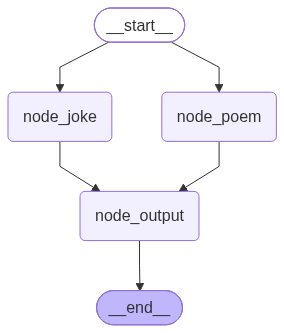

In [2]:
from IPython.display import display

display(graph)

### 履歴のノートをチェック

In [4]:
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

[
    StateSnapshot(
        values={
            'topic': '蓮の花',
            'poem': '蓮の花 泥より立ちて 
空仰ぐ\n\n季語：蓮の花（夏）\n泥水の中から清らかな花を咲かせる蓮の姿を詠みました。汚泥に根を張りながらも、濁りを知
らぬかのように天上へと真っ直ぐ伸びる花の気高さを表現しています。',
            'joke': 
'蓮の花をテーマにしたジョーク、いくつかお届けします。\n\n**その1（ダジャレ系）**\n「蓮の花がデートに行くと言うので
、『どこに行くの？』と聞いたら、『ハス（はず）がないでしょ、泥の中で待ってるわ』って言われた。」\n\n**その2（擬人化
系）**\n泥の中で暮らす蓮の根っこが、水面の葉っぱに愚痴をこぼした。\n「お前は毎日、太陽の光を浴びてキラキラしててい
いよな。俺なんてずっと真っ暗な泥の中だぜ。」\nすると葉っぱが言った。\n「そんなこと言わないでよ。お前が頑張ってるか
ら、僕たちがこうして咲けるんだよ。それに――」\n「それに？」\n「お前もいつか、お花（お世話）を焼かれる日が来るんだか
らさ。」\n\n**その3（仏教風の一発ギャグ）**\n「蓮の花が座禅を組んでるのを見た坊主が、『お前も悟りを開いたか？』と尋
ねると、蓮の花は答えた。\n『いや、ただのハスのポーズだよ。』」\n\n**その4（現代風の自虐ネタ）**\n「蓮の花は“泥中の
蓮”って言われるけどさ、あれってよく考えると『周りがドロドロしてるから、自分がキレイに見えるだけ』ってことだよな。\n
……俺のSNSのプロフィール写真も、同じ理論で盛ってるわ。」\n\nいかがでしょうか。蓮の花は「汚れた泥の中から清らかに咲く
」というイメージが強いので、そこを逆手に取ったジョークが多いですね。',
            'final_output': '蓮の花をテーマにした俳句:蓮の花 泥より立ちて 
空仰ぐ\n\n季語：蓮の花（夏）\n泥水の中から清らかな花を咲かせる蓮の姿を詠みました。汚泥に根を張りながらも、濁りを知
らぬかのように天上へと真っ直ぐ伸びる花の気高さを表現しています。,\nジョーク:蓮の花をテーマにしたジョーク、いくつか
お届けします。\n\n**その1（ダジャレ系）**\n「蓮の花がデートに行くと言うので、『どこに行くの？』と聞いたら、『ハス（
はず）がないでしょ、泥の中で待ってるわ』って言われた。」\n\n**その2（擬人化系）**\n泥の中で暮らす蓮の根っこが、水面
の葉っぱに愚痴をこぼした。\n「お前は毎日、太陽の光を浴びてキラキラしてていいよな。俺なんてずっと真っ暗な泥の中だぜ
。」\nすると葉っぱが言った。\n「そんなこと言わないでよ。お前が頑張ってるから、僕たちがこうして咲けるんだよ。それに―
―」\n「それに？」\n「お前もいつか、お花（お世話）を焼かれる日が来るんだからさ。」\n\n**その3（仏教風の一発ギャグ）*
*\n「蓮の花が座禅を組んでるのを見た坊主が、『お前も悟りを開いたか？』と尋ねると、蓮の花は答えた。\n『いや、ただのハ
スのポーズだよ。』」\n\n**その4（現代風の自虐ネタ）**\n「蓮の花は“泥中の蓮”って言われるけどさ、あれってよく考えると
『周りがドロドロしてるから、自分がキレイに見えるだけ』ってことだよな。\n……俺のSNSのプロフィール写真も、同じ理論で盛
ってるわ。」\n\nいかがでしょうか。蓮の花は「汚れた泥の中から清らかに咲く」というイメージが強いので、そこを逆手に取
ったジョークが多いですね。\n'
        },
        next=(),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f198169-d2f1-6c8d-8002-69dbc039bd1d'
            }
        },
        metadata={'source': 'loop', 'step': 2, 'parents': {}},
        created_at='2026-08-14T19:30:31.900883+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f198169-d2ee-65cb-8001-90d1bddfd0ec'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={
            'topic': '蓮の花',
            'poem': '蓮の花 泥より立ちて 
空仰ぐ\n\n季語：蓮の花（夏）\n泥水の中から清らかな花を咲かせる蓮の姿を詠みました。汚泥に根を張りながらも、濁りを知
らぬかのように天上へと真っ直ぐ伸びる花の気高さを表現しています。',
            'joke': 
'蓮の花をテーマにしたジョーク、いくつかお届けします。\n\n**その1（ダジャレ系）**\n「蓮の花がデートに行くと言うので
、『どこに行くの？』と聞いたら、『ハス（はず）がないでしょ、泥の中で待ってるわ』って言われた。」\n\n**その2（擬人化
系）**\n泥の中で暮らす蓮の根っこが、水面の葉っぱに愚痴をこぼした。\n「お前は毎日、太陽の光を浴びてキラキラしててい
いよな。俺なんてずっと真っ暗な泥の中だぜ。」\nすると葉っぱが言った。\n「そんなこと言わないでよ。お前が頑張ってるか
ら、僕たちがこうして咲けるんだよ。それに――」\n「それに？」\n「お前もいつか、お花（お世話）を焼かれる日が来るんだか
らさ。」\n\n**その3（仏教風の一発ギャグ）**\n「蓮の花が座禅を組んでるのを見た坊主が、『お前も悟りを開いたか？』と尋
ねると、蓮の花は答えた。\n『いや、ただのハスのポーズだよ。』」\n\n**その4（現代風の自虐ネタ）**\n「蓮の花は“泥中の
蓮”って言われるけどさ、あれってよく考えると『周りがドロドロしてるから、自分がキレイに見えるだけ』ってことだよな。\n
……俺のSNSのプロフィール写真も、同じ理論で盛ってるわ。」\n\nいかがでしょうか。蓮の花は「汚れた泥の中から清らかに咲く
」というイメージが強いので、そこを逆手に取ったジョークが多いですね。'
        },
        next=('node_output',),
        config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f198169-d2ee-65cb-8001-90d1bddfd0ec'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-08-14T19:30:31.899480+00:00',
        parent_config={
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f198169-8ef1-6caf-8000-f18e07dab9cf'
            }
        },
        tasks=(
            PregelTask(
                id='cc478848-ed06-97aa-30b1-6edd2269c2a5',
                name='node_output',
                path=('__pregel_pull', 'node_output'),
                error=None,
                interrupts=(),
                state=None,
                result={
                    'final_output': '蓮の花をテーマにした俳句:蓮の花 泥より立ちて 
空仰ぐ\n\n季語：蓮の花（夏）\n泥水の中から清

In [5]:
latest_history_checkpoint = graph.get_state(config=config)
print(latest_history_checkpoint)

StateSnapshot(
    values={
        'topic': '蓮の花',
        'poem': '蓮の花 泥より立ちて 
空仰ぐ\n\n季語：蓮の花（夏）\n泥水の中から清らかな花を咲かせる蓮の姿を詠みました。汚泥に根を張りながらも、濁りを知
らぬかのように天上へと真っ直ぐ伸びる花の気高さを表現しています。',
        'joke': 
'蓮の花をテーマにしたジョーク、いくつかお届けします。\n\n**その1（ダジャレ系）**\n「蓮の花がデートに行くと言うので
、『どこに行くの？』と聞いたら、『ハス（はず）がないでしょ、泥の中で待ってるわ』って言われた。」\n\n**その2（擬人化
系）**\n泥の中で暮らす蓮の根っこが、水面の葉っぱに愚痴をこぼした。\n「お前は毎日、太陽の光を浴びてキラキラしててい
いよな。俺なんてずっと真っ暗な泥の中だぜ。」\nすると葉っぱが言った。\n「そんなこと言わないでよ。お前が頑張ってるか
ら、僕たちがこうして咲けるんだよ。それに――」\n「それに？」\n「お前もいつか、お花（お世話）を焼かれる日が来るんだか
らさ。」\n\n**その3（仏教風の一発ギャグ）**\n「蓮の花が座禅を組んでるのを見た坊主が、『お前も悟りを開いたか？』と尋
ねると、蓮の花は答えた。\n『いや、ただのハスのポーズだよ。』」\n\n**その4（現代風の自虐ネタ）**\n「蓮の花は“泥中の
蓮”って言われるけどさ、あれってよく考えると『周りがドロドロしてるから、自分がキレイに見えるだけ』ってことだよな。\n
……俺のSNSのプロフィール写真も、同じ理論で盛ってるわ。」\n\nいかがでしょうか。蓮の花は「汚れた泥の中から清らかに咲く
」というイメージが強いので、そこを逆手に取ったジョークが多いですね。',
        'final_output': '蓮の花をテーマにした俳句:蓮の花 泥より立ちて 
空仰ぐ\n\n季語：蓮の花（夏）\n泥水の中から清らかな花を咲かせる蓮の姿を詠みました。汚泥に根を張りながらも、濁りを知
らぬかのように天上へと真っ直ぐ伸びる花の気高さを表現しています。,\nジョーク:蓮の花をテーマにしたジョーク、いくつか
お届けします。\n\n**その1（ダジャレ系）**\n「蓮の花がデートに行くと言うので、『どこに行くの？』と聞いたら、『ハス（
はず）がないでしょ、泥の中で待ってるわ』って言われた。」\n\n**その2（擬人化系）**\n泥の中で暮らす蓮の根っこが、水面
の葉っぱに愚痴をこぼした。\n「お前は毎日、太陽の光を浴びてキラキラしてていいよな。俺なんてずっと真っ暗な泥の中だぜ
。」\nすると葉っぱが言った。\n「そんなこと言わないでよ。お前が頑張ってるから、僕たちがこうして咲けるんだよ。それに―
―」\n「それに？」\n「お前もいつか、お花（お世話）を焼かれる日が来るんだからさ。」\n\n**その3（仏教風の一発ギャグ）*
*\n「蓮の花が座禅を組んでるのを見た坊主が、『お前も悟りを開いたか？』と尋ねると、蓮の花は答えた。\n『いや、ただのハ
スのポーズだよ。』」\n\n**その4（現代風の自虐ネタ）**\n「蓮の花は“泥中の蓮”って言われるけどさ、あれってよく考えると
『周りがドロドロしてるから、自分がキレイに見えるだけ』ってことだよな。\n……俺のSNSのプロフィール写真も、同じ理論で盛
ってるわ。」\n\nいかがでしょうか。蓮の花は「汚れた泥の中から清らかに咲く」というイメージが強いので、そこを逆手に取
ったジョークが多いですね。\n'
    },
    next=(),
    config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f198169-d2f1-6c8d-8002-69dbc039bd1d'
        }
    },
    metadata={'source': 'loop', 'step': 2, 'parents': {}},
    created_at='2026-08-14T19:30:31.900883+00:00',
    parent_config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f198169-d2ee-65cb-8001-90d1bddfd0ec'
        }
    },
    tasks=(),
    interrupts=()
)

In [7]:
target_config = {
    "configurable": {
        "thread_id": "123",
        "checkpoint_id": "1f198169-8eef-6902-bfff-4371b81a0350"
    }
}

snapshot = graph.get_state(config=target_config)
print(snapshot)

StateSnapshot(
    values={},
    next=('__start__',),
    config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f198169-8eef-6902-bfff-4371b81a0350'}},
    metadata={'source': 'input', 'step': -1, 'parents': {}},
    created_at='2026-08-14T19:30:24.769656+00:00',
    parent_config=None,
    tasks=(
        PregelTask(
            id='b5803fc1-a225-5bb2-6f2f-774f7feba1f5',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={'topic': '蓮の花'}
        ),
    ),
    interrupts=()
)

In [8]:
print('=' * 30, '-> IDを指定して特定のチェックポイントを確認 <-', '=' * 30)
checkpointe_id = history_checkpoints[-2].config["configurable"]["checkpoint_id"]
print(f"checkpointe_id: {checkpointe_id}")

target_config = {
    "configurable": {
        "thread_id": config["configurable"]["thread_id"],
        "checkpoint_id": checkpointe_id
    }
}

specific_history_checkpoint = graph.get_state(config=target_config)
print(specific_history_checkpoint)

============================== -> IDを指定して特定のチェックポイントを確認 <- ==============================

checkpointe_id: 1f198169-8ef1-6caf-8000-f18e07dab9cf

StateSnapshot(
    values={'topic': '蓮の花'},
    next=('node_poem', 'node_joke'),
    config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f198169-8ef1-6caf-8000-f18e07dab9cf'}},
    metadata={'source': 'loop', 'step': 0, 'parents': {}},
    created_at='2026-08-14T19:30:24.770568+00:00',
    parent_config={
        'configurable': {
            'thread_id': '123',
            'checkpoint_ns': '',
            'checkpoint_id': '1f198169-8eef-6902-bfff-4371b81a0350'
        }
    },
    tasks=(
        PregelTask(
            id='efe2ec4a-dbf0-57d7-3499-018e9771d258',
            name='node_poem',
            path=('__pregel_pull', 'node_poem'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'poem': '蓮の花 泥より立ちて 
空仰ぐ\n\n季語：蓮の花（夏）\n泥水の中から清らかな花を咲かせる蓮の姿を詠みました。汚泥に根を張りながらも、濁りを知
らぬかのように天上へと真っ直ぐ伸びる花の気高さを表現しています。'
            }
        ),
        PregelTask(
            id='d6865d23-fb75-e02b-47c1-5658069f6c8c',
            name='node_joke',
            path=('__pregel_pull', 'node_joke'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'joke': 
'蓮の花をテーマにしたジョーク、いくつかお届けします。\n\n**その1（ダジャレ系）**\n「蓮の花がデートに行くと言うので
、『どこに行くの？』と聞いたら、『ハス（はず）がないでしょ、泥の中で待ってるわ』って言われた。」\n\n**その2（擬人化
系）**\n泥の中で暮らす蓮の根っこが、水面の葉っぱに愚痴をこぼした。\n「お前は毎日、太陽の光を浴びてキラキラしててい
いよな。俺なんてずっと真っ暗な泥の中だぜ。」\nすると葉っぱが言った。\n「そんなこと言わないでよ。お前が頑張ってるか
ら、僕たちがこうして咲けるんだよ。それに――」\n「それに？」\n「お前もいつか、お花（お世話）を焼かれる日が来るんだか
らさ。」\n\n**その3（仏教風の一発ギャグ）**\n「蓮の花が座禅を組んでるのを見た坊主が、『お前も悟りを開いたか？』と尋
ねると、蓮の花は答えた。\n『いや、ただのハスのポーズだよ。』」\n\n**その4（現代風の自虐ネタ）**\n「蓮の花は“泥中の
蓮”って言われるけどさ、あれってよく考えると『周りがドロドロしてるから、自分がキレイに見えるだけ』ってことだよな。\n
……俺のSNSのプロフィール写真も、同じ理論で盛ってるわ。」\n\nいかがでしょうか。蓮の花は「汚れた泥の中から清らかに咲く
」というイメージが強いので、そこを逆手に取ったジョークが多いですね。'
            }
        )
    ),
    interrupts=()
)